# 03 - Perception and image rendering

**Goal.** Replace direct access to the state with a *camera*. We derive the pinhole
projection, use it to render small synthetic road images, and model the ways the
real world degrades them. This gives a controllable, perfectly-labelled stand-in
for a perception sensor - and, crucially, a way to leave its operating domain on
demand.

Why *synthetic* images? Because we get exact ground truth for free, we can dial any
degradation continuously, and we need no dataset. The point of the course is not
computer vision accuracy but the *trustworthy use* of a perception estimate in a
control loop, so a transparent renderer is the right tool.

## 1. The pinhole camera

A pinhole camera projects a 3D point onto the image plane by a perspective
division. Let a point have coordinates $(X_c, Y_c, Z_c)$ in the camera frame, with
$Z_c$ along the optical axis. By **similar triangles** the point at depth $Z_c$
scales to the image plane at focal length $f$:

$$ u = f\,\frac{X_c}{Z_c} + c_x, \qquad v = f\,\frac{Y_c}{Z_c} + c_y, $$

where $(c_x, c_y)$ is the principal point. In homogeneous coordinates this is linear
[1,2]:

$$ Z_c\begin{bmatrix}u\\ v\\ 1\end{bmatrix}
   = K\begin{bmatrix}X_c\\ Y_c\\ Z_c\end{bmatrix},\qquad
   K=\begin{bmatrix} f & 0 & c_x\\ 0 & f & c_y\\ 0 & 0 & 1\end{bmatrix}. $$

The nonlinearity that matters is the division by $Z_c$: near things are large, far
things shrink, and parallel lines converge.

## 2. The road is a plane: forward-camera geometry

For lane keeping the scene of interest is the **ground plane**. Mount the camera at
height $h$ above the road with its optical axis pointing forward along the road, so
that in camera coordinates a ground point at longitudinal distance $s$ ahead and
lateral offset $y$ has $Z_c = s$ (depth), $X_c = y$ (right), and $Y_c = h$ (the road
is $h$ below the camera). Substituting into the pinhole equations:

$$ \boxed{\;u = c_x + f\,\frac{y}{s},\qquad v = c_y + f\,\frac{h}{s}\;} $$

Two consequences are worth noting. As $s\to\infty$ the projection tends to
$(c_x, c_y)$ regardless of $y$: **all lane lines converge to a single vanishing
point on the horizon** at row $v=c_y$. And because the road is planar, the whole
road-to-image map is a $3\times 3$ **homography** [1] - a fact lane-detection
systems exploit to "flatten" the road into a bird's-eye view.

The lane centreline, in the vehicle frame, is well approximated to second order in
look-ahead by a parabola (a clothoid segment linearised in $s$) [4,5]:

$$ y_{road}(s) = -e_y - e_\psi\,s + \tfrac12\,\kappa\,s^2, $$

the three terms being the lateral offset, the drift due to heading error, and the
road curvature. Lane markings sit at $y_{road}(s)\pm w/2$.

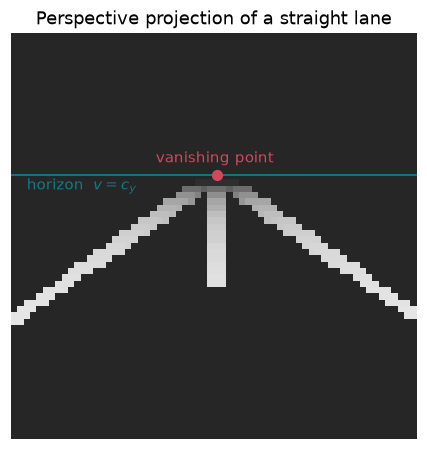

In [1]:
import numpy as np, matplotlib.pyplot as plt

Himg = Wimg = 64
FOCAL, CAM_H, HORIZON = 55.0, 1.25, 0.34*Himg     # focal [px], camera height [m], horizon row

def project(s, y):
    return Wimg/2 + FOCAL*y/s, HORIZON + FOCAL*CAM_H/s

def gaussian_blur(img, sigma):
    if sigma <= 1e-3: return img
    r = max(1, int(round(3*sigma))); xk = np.arange(-r, r+1)
    k = np.exp(-0.5*(xk/sigma)**2); k /= k.sum()
    out = np.apply_along_axis(lambda m: np.convolve(m, k, 'same'), 0, img)
    return np.apply_along_axis(lambda m: np.convolve(m, k, 'same'), 1, out)

def render(e_y, e_psi, kappa, brightness=1.0, blur=0.0, occ=0.0, noise=0.02, seed=0):
    rng = np.random.default_rng(seed)
    img = np.full((Himg, Wimg), 0.15, np.float32)     # dark asphalt
    s = np.linspace(3, 45, 400)
    yc = -e_y - e_psi*s + 0.5*kappa*s**2
    fade = np.clip(1 - (s-3)/42, .2, 1)               # far markings dimmer
    for off, dashed in ((-1.75, False), (1.75, False), (0.0, True)):
        u, v = project(s, yc + off)
        for i in range(len(s)):
            if dashed and int(s[i]) % 3 == 0: continue
            rr, cc = int(round(v[i])), int(round(u[i]))
            if 0 <= rr < Himg and 0 <= cc < Wimg:
                for dc in (-1, 0, 1):
                    if 0 <= cc+dc < Wimg: img[rr, cc+dc] = max(img[rr, cc+dc], 0.9*fade[i])
    img = img * brightness
    if occ > 0:
        top = int(HORIZON); img[top:top+int(occ*(Himg-top))] = 0.05
    img = gaussian_blur(img, blur)
    return np.clip(img + rng.normal(0, noise, img.shape), 0, 1)

# a clean straight lane, with the horizon and vanishing point marked
img = render(0.0, 0.0, 0.0, noise=0.0)
plt.figure(figsize=(4.2, 4.2))
plt.imshow(img, cmap="gray", vmin=0, vmax=1)
plt.axhline(HORIZON, color="#0e7c8b", lw=1.2)
plt.scatter([Wimg/2], [HORIZON], color="#d1495b", s=40, zorder=3)
plt.annotate("vanishing point", (Wimg/2, HORIZON), color="#d1495b",
             textcoords="offset points", xytext=(-40, 8))
plt.annotate("horizon  $v=c_y$", (2, HORIZON), color="#0e7c8b",
             textcoords="offset points", xytext=(0, -10))
plt.title("Perspective projection of a straight lane"); plt.axis("off")
plt.tight_layout(); plt.show()

## 3. Modelling the degradations

Each condition the ODD monitor watches corresponds to a physical or measurement
process [2,3]:

- **Defocus / atmospheric blur** is a convolution with a **point-spread function
  (PSF)**. A Gaussian PSF of standard deviation $\sigma$ is the standard
  approximation, $I_{blur} = I * g_\sigma$. It is *separable*, so we apply a 1-D
  kernel along rows then columns.
- **Illumination** acts as a multiplicative gain $I \mapsto b\,I$ (ignoring gamma).
- **Occlusion** removes a region of the image (missing data), here a band of the far
  road.
- **Sensor noise** is additive; read noise is well modelled as Gaussian
  $\mathcal N(0,\sigma_n^2)$, shot noise as Poisson [6]. We use additive Gaussian.

Below: the Gaussian PSF kernel and its effect on the rendered lane.

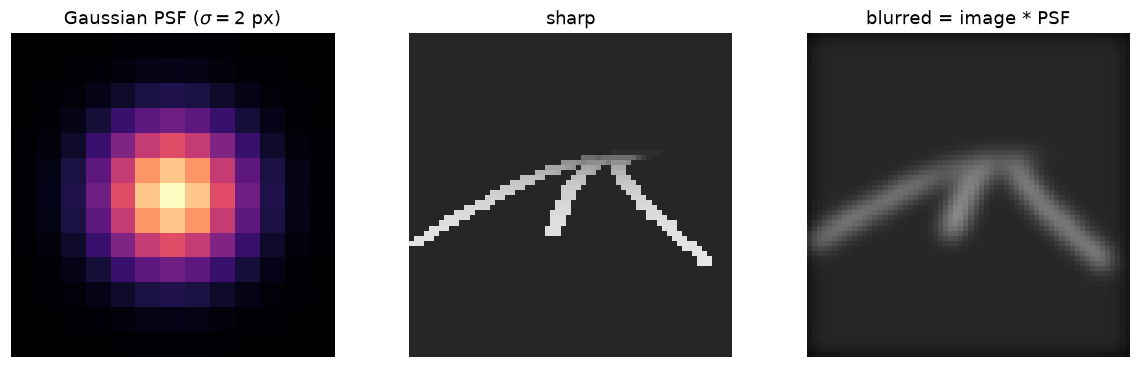

In [2]:
sigma = 2.0
r = int(round(3*sigma)); ax_ = np.arange(-r, r+1)
k1 = np.exp(-0.5*(ax_/sigma)**2); k1 /= k1.sum()
psf = np.outer(k1, k1)                              # 2-D separable Gaussian PSF

fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
ax[0].imshow(psf, cmap="magma"); ax[0].set_title("Gaussian PSF ($\\sigma=2$ px)"); ax[0].axis("off")
ax[1].imshow(render(0.3, 0.02, 0.012, noise=0.0), cmap="gray", vmin=0, vmax=1)
ax[1].set_title("sharp"); ax[1].axis("off")
ax[2].imshow(render(0.3, 0.02, 0.012, blur=sigma, noise=0.0), cmap="gray", vmin=0, vmax=1)
ax[2].set_title("blurred = image $*$ PSF"); ax[2].axis("off")
plt.tight_layout(); plt.show()

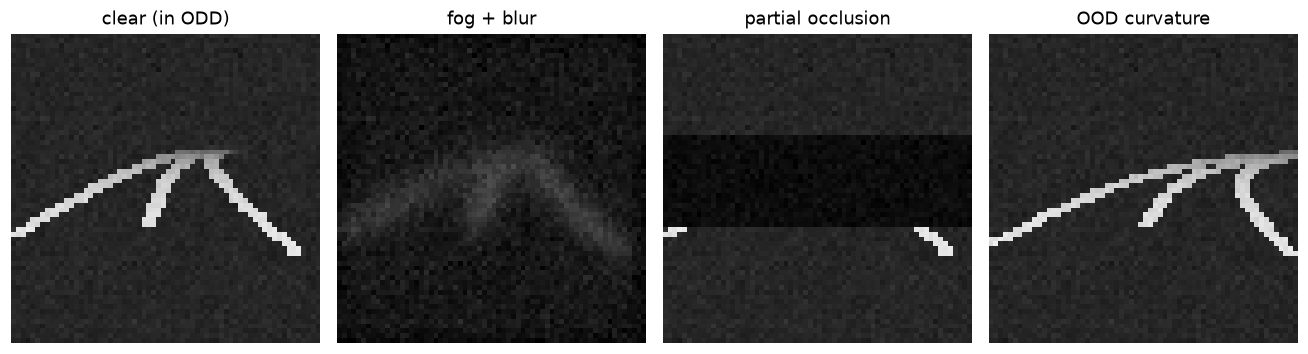

In [3]:
# The four regimes used throughout the course
panels = [("clear (in ODD)",      dict(kappa=0.012)),
          ("fog + blur",          dict(kappa=0.012, brightness=0.6, blur=2.6, noise=0.03)),
          ("partial occlusion",   dict(kappa=0.012, occ=0.45)),
          ("OOD curvature",       dict(kappa=0.05))]
fig, ax = plt.subplots(1, 4, figsize=(12, 3.2))
for a, (name, kw) in zip(ax, panels):
    a.imshow(render(0.3, 0.02, **kw), cmap="gray", vmin=0, vmax=1)
    a.set_title(name); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Cheap pixel features for the ODD monitor

The operational-design-domain monitor (notebook 06) does not have the true
conditions; it must estimate them from the image. Two very cheap statistics suffice
as proxies:

- **Brightness** = mean intensity, tracking the illumination gain.
- **Sharpness** = mean squared image gradient (a Tenengrad-style focus measure),
  which falls as blur rises because convolution with the PSF attenuates high
  spatial frequencies [3].

Both are monotone in their degradation, so a simple threshold on them detects
"outside the ODD" from pixels alone.

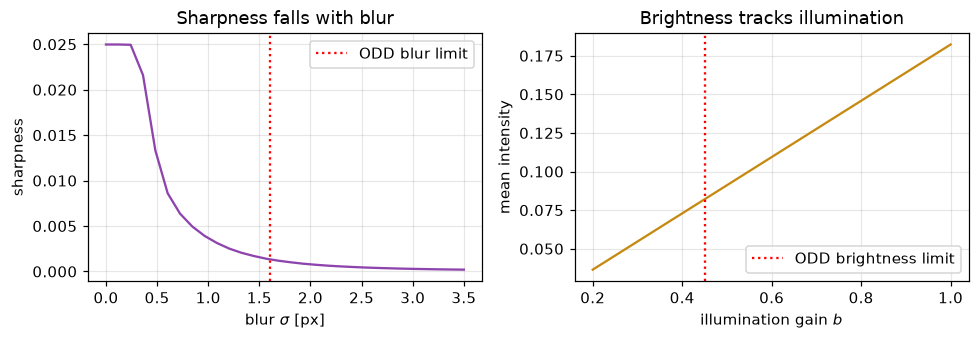

In [4]:
def brightness_feat(img): return float(img.mean())
def sharpness_feat(img):
    gx = np.diff(img, axis=1); gy = np.diff(img, axis=0)
    return float(np.mean(gx**2) + np.mean(gy**2))

blurs = np.linspace(0, 3.5, 30)
sh = [sharpness_feat(render(0.3, 0.02, 0.012, blur=b, noise=0.0)) for b in blurs]
brs = np.linspace(0.2, 1.0, 30)
br = [brightness_feat(render(0.3, 0.02, 0.012, brightness=b, noise=0.0)) for b in brs]

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(blurs, sh, color="#8e44ad"); ax[0].axvline(1.6, ls=":", color="r", label="ODD blur limit")
ax[0].set(xlabel="blur $\\sigma$ [px]", ylabel="sharpness", title="Sharpness falls with blur"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(brs, br, color="#c68a12"); ax[1].axvline(0.45, ls=":", color="r", label="ODD brightness limit")
ax[1].set(xlabel="illumination gain $b$", ylabel="mean intensity", title="Brightness tracks illumination"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Why out-of-distribution curvature is invisible in the pixels

Blur, darkness and occlusion are *visible* degradations: they change the image
statistics, so a pixel-level monitor can flag them. An **out-of-distribution
curvature is different**. A sharper-than-trained curve still renders as a perfectly
clean, well-exposed, in-focus lane - its brightness and sharpness are essentially
those of an in-domain curve. Nothing local in the pixels says "you have never seen
this geometry."

This is the crux of the whole course. The novelty lives in the *regime*, not in the
image quality, so no amount of pixel-level confidence or image-feature monitoring
will catch it. Detecting it requires comparing the perception output against a
*model of the dynamics* - the innovation / NIS test of notebook 05.

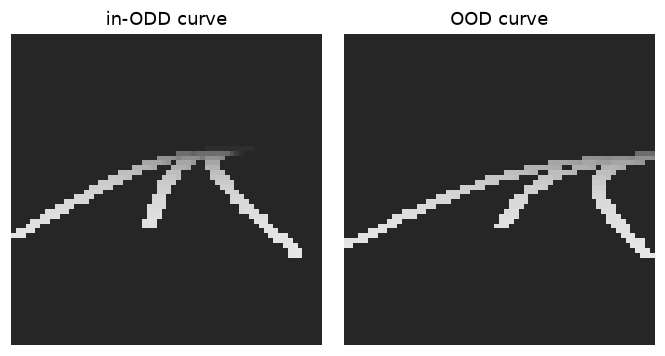

                 sharpness   brightness
in-ODD curve :     0.0250       0.182
OOD curve    :     0.0292       0.187

Pixel statistics are nearly identical - the images look equally valid.


In [5]:
in_odd  = render(0.3, 0.02, 0.012, noise=0.0)   # trained curvature
ood     = render(0.3, 0.02, 0.050, noise=0.0)   # out-of-distribution curvature, still a clean image
print("                 sharpness   brightness")
print("in-ODD curve : %10.4f %11.3f" % (sharpness_feat(in_odd),  brightness_feat(in_odd)))
print("OOD curve    : %10.4f %11.3f" % (sharpness_feat(ood),     brightness_feat(ood)))
print()
print("Pixel statistics are nearly identical - the images look equally valid.")

fig, ax = plt.subplots(1, 2, figsize=(6.2, 3.2))
ax[0].imshow(in_odd, cmap="gray", vmin=0, vmax=1); ax[0].set_title("in-ODD curve"); ax[0].axis("off")
ax[1].imshow(ood,    cmap="gray", vmin=0, vmax=1); ax[1].set_title("OOD curve"); ax[1].axis("off")
plt.tight_layout(); plt.show()

### Exercises

1. Derive the vanishing-point row $v=c_y$ by taking $s\to\infty$ in the projection.
   Where does the lateral offset $e_y$ go in that limit, and why?
2. The bird's-eye ("inverse perspective") view undoes the homography. Using
   $u=c_x+f y/s,\ v=c_y+f h/s$, solve for $(s, y)$ given $(u, v)$ and map the clear
   image back to a top-down road. What happens to noise near the horizon?
3. Replace the Gaussian PSF with a uniform disc (defocus) kernel of the same radius.
   How does the sharpness-vs-blur curve change?
4. Add a *gamma* nonlinearity $I\mapsto I^{\gamma}$ to the illumination model and
   check whether mean intensity is still a good brightness proxy.

## References

1. R. Hartley, A. Zisserman. *Multiple View Geometry in Computer Vision,* 2nd ed. Cambridge University Press, 2004. (Pinhole model, planar homography, vanishing points.)
2. R. Szeliski. *Computer Vision: Algorithms and Applications,* 2nd ed. Springer, 2022. (Image formation, blur, noise.)
3. R. C. Gonzalez, R. E. Woods. *Digital Image Processing,* 4th ed. Pearson, 2018. (Point-spread functions, convolution, focus measures, noise models.)
4. E. D. Dickmanns, B. D. Mysliwetz. *Recursive 3-D road and relative ego-state recognition.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 14(2):199-213, 1992. doi:10.1109/34.126801 (Clothoid lane model.)
5. J. C. McCall, M. M. Trivedi. *Video-based lane estimation and tracking for driver assistance.* IEEE Transactions on Intelligent Transportation Systems, 7(1):20-37, 2006. doi:10.1109/TITS.2006.869595 (The $y=a+bs+cs^2$ lane model.)
6. G. E. Healey, R. Kondepudy. *Radiometric CCD camera calibration and noise estimation.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 16(3):267-276, 1994. doi:10.1109/34.276126 (Sensor noise model.)